In [173]:
#Part 1
%pip install pandas numpy matplotlib scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import random

Note: you may need to restart the kernel to use updated packages.


In [174]:
#Part 2
df = pd.read_csv('clean_data.csv')
print(f"Data Size: {df.shape}")
df.head()

Data Size: (2672, 18)


,id,screen_name,location,description,url,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot
0,8.160000e+17,"""HoustonPokeMap""","""Houston, TX""","""Rare and strong PokŽmon in Houston, TX. See m...","""https://t.co/dnWuDbFRkt""",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1
1,4.843621e+09,kernyeahx,"Templeville town, MD, USA",From late 2014 Socium Marketplace will make sh...,NaN,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1
2,4.303727e+09,mattlieberisbot,NaN,"Inspired by the smart, funny folks at @replyal...",https://t.co/P1e1o0m4KC,1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1
3,3.063139e+09,sc_papers,NaN,NaN,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1
4,2.955142e+09,lucarivera16,"Dublin, United States",Inspiring cooks everywhere since 1956.,NaN,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1


In [175]:
#Part 3
for column_name in list(df.columns):
    missing_percentage = df[column_name].isnull().mean() * 100
    if missing_percentage > 35:
        df.drop(column_name, axis=1, inplace = True)

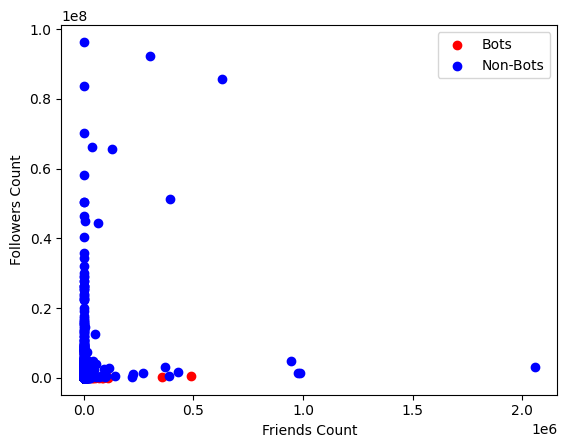

In [176]:
#Part 4
bots = df[df['bot'] == 1]
nonbots = df[df['bot'] == 0]

plt.scatter(bots['friends_count'], bots['followers_count'], color='red', label='Bots')
plt.scatter(nonbots['friends_count'], nonbots['followers_count'], color='blue', label='Non-Bots')

plt.legend()
plt.xlabel('Friends Count')
plt.ylabel('Followers Count')
plt.show()

In [177]:
#Part 5
bag_of_words = ['bot', 'follow me', 'free', 'fake', 'virus', 'troll', 'clone', 'tweet me']
def checkbag(text):
    return any(word in str(text).lower() for word in bag_of_words)
df['screen_name_binary'] = df['screen_name'].apply(checkbag)
df['name_binary'] = df['name'].apply(checkbag)
df['description_binary'] = df['description'].apply(checkbag)
df['status_binary'] = df['status'].apply(checkbag)

df.head()

,id,screen_name,description,followers_count,friends_count,listed_count,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,name,bot,screen_name_binary,name_binary,description_binary,status_binary
0,8.160000e+17,"""HoustonPokeMap""","""Rare and strong PokŽmon in Houston, TX. See m...",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\n ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,"""Houston PokŽ Alert""",1,False,False,False,False
1,4.843621e+09,kernyeahx,From late 2014 Socium Marketplace will make sh...,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,Keri Nelson,1,False,False,False,False
2,4.303727e+09,mattlieberisbot,"Inspired by the smart, funny folks at @replyal...",1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,Matt Lieber Is Bot,1,True,True,True,True
3,3.063139e+09,sc_papers,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,single cell papers,1,False,False,False,False
4,2.955142e+09,lucarivera16,Inspiring cooks everywhere since 1956.,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,lucarivera16,1,False,False,False,False


In [178]:
#Part 6
x = df[['friends_count', 'followers_count', 'screen_name_binary', 'name_binary', 'status_binary', 'verified', 'statuses_count']]
y = df['bot']
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.3)

clf = DecisionTreeClassifier(criterion='entropy')
#clf.fit(x,y)
#Runs the classifier on the training data sets
clf.fit(X_train, Y_train)

#Predicts given the training data as the input
y_pred_train = clf.predict(X_train)
#Predicts given the testing data as the input
y_pred_test = clf.predict(X_test)

print("Training Accuracy: ", metrics.accuracy_score(Y_train,y_pred_train))
print("Testing Accuracy: ", metrics.accuracy_score(Y_test,y_pred_test))
print(export_text(clf, feature_names=list(x.columns)))




Training Accuracy:  0.9989304812834224
Testing Accuracy:  0.8628428927680798
|--- verified <= 0.50
|   |--- friends_count <= 5.50
|   |   |--- followers_count <= 27967.50
|   |   |   |--- statuses_count <= 35.00
|   |   |   |   |--- friends_count <= 4.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- friends_count >  4.00
|   |   |   |   |   |--- name_binary <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- name_binary >  0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- statuses_count >  35.00
|   |   |   |   |--- statuses_count <= 8176.00
|   |   |   |   |   |--- statuses_count <= 7885.00
|   |   |   |   |   |   |--- followers_count <= 265.00
|   |   |   |   |   |   |   |--- statuses_count <= 488.00
|   |   |   |   |   |   |   |   |--- statuses_count <= 453.00
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- statuses_count >  453.00
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   | 

In [179]:
#Part 7
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train, Y_train)

y_pred_train_lr = clf_lr.predict(X_train)
y_pred_test_lr = clf_lr.predict(X_test)
print("Training Accuracy: ", metrics.accuracy_score(Y_train,y_pred_train_lr))
print("Testing Accuracy: ", metrics.accuracy_score(Y_test,y_pred_test_lr))

Training Accuracy:  0.6946524064171123
Testing Accuracy:  0.6932668329177057


In [180]:
#Short Answers for part 1
'''
1. Based on the plot in step 4 part 1, I can determine that we can use friends_count and followers_count
for classification because the graph shows that bots tend to group together.
2. For the decision tree, the training accuracy was 0.9989304812834224 with a testing accuracy of 0.85785536159601. 
The test accuracy better represents the quality of the classifier because it does not have the problem of overfitting.
3. For this specific task, the DecisionTree classifier is better because the dataset is nonlinear.
4. After fitting, the decision tree classifies users by only splitting twice. It tells us that the classifier thinks the most important
variables for detecting bots are the friends_count and the verificiation because those are what the classifier splits on.
5. In both the test and training data there are around 46% bots. In a scenerio with 10% bots and 85% accuracy, a  classifier that guesses that every user is not a bot would score a 90%, a score higher than the trained classifier.
6. Some problems that arise might be if the data is sorted by time or other factors. This would induce bias into the model where the model would only train only on data that came from a certain time slice.
To fix this, we can randomize creating the testing and training data to better represent the total population of the dataset.
7. Dropping columns with over 35% missing values, Choosing what words gets put into the bag of words, choosing only a selected subset of the datadrame to be used for our model, using the entrophy criterion, and splitting the training and testing data into a 70:30 ratio.
'''

'\n1. Based on the plot in step 4 part 1, I can determine that we can use friends_count and followers_count\nfor classification because the graph shows that bots tend to group together.\n2. For the decision tree, the training accuracy was 0.9989304812834224 with a testing accuracy of 0.85785536159601. \nThe test accuracy better represents the quality of the classifier because it does not have the problem of overfitting.\n3. For this specific task, the DecisionTree classifier is better because the dataset is nonlinear.\n4. After fitting, the decision tree classifies users by only splitting twice. It tells us that the classifier thinks the most important\nvariables for detecting bots are the friends_count and the verificiation because those are what the classifier splits on.\n5. In both the test and training data there are around 46% bots. In a scenerio with 10% bots and 85% accuracy, a  classifier that guesses that every user is not a bot would score a 90%, a score higher than the train

In [181]:
#DecisionTree depth 2

x = df[['friends_count', 'followers_count', 'screen_name_binary', 'name_binary', 'status_binary', 'verified', 'statuses_count']]
y = df['bot']
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.3)

clf = DecisionTreeClassifier(criterion='entropy', max_depth = 2)
#clf.fit(x,y)
clf.fit(X_train, Y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
print("Training Accuracy: ", metrics.accuracy_score(Y_train,y_pred_train))
print("Testing Accuracy: ", metrics.accuracy_score(Y_test,y_pred_test))
print(export_text(clf, feature_names=list(x.columns)))




Training Accuracy:  0.7449197860962566
Testing Accuracy:  0.7456359102244389
|--- verified <= 0.50
|   |--- friends_count <= 6.50
|   |   |--- class: 1
|   |--- friends_count >  6.50
|   |   |--- class: 0
|--- verified >  0.50
|   |--- statuses_count <= 6016.50
|   |   |--- class: 0
|   |--- statuses_count >  6016.50
|   |   |--- class: 0



In [182]:
#Step 1
X1s = np.random.random(1000)
X2s = np.random.random(1000)
Ys = X1s+X2s > 1
df2 = pd.DataFrame({'X1':X1s,'X2':X2s,'Y':Ys})

print(df2.head())



         X1        X2      Y
0  0.140725  0.455137  False
1  0.065389  0.520018  False
2  0.587983  0.721778   True
3  0.965374  0.090693   True
4  0.638279  0.743698   True


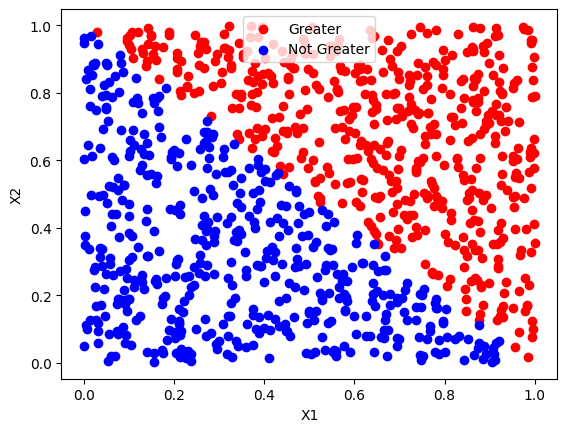

In [183]:
#Step 2
Greater = df2[df2['Y'] == 1]
NotGreater = df2[df2['Y'] == 0]

plt.scatter(Greater['X1'], Greater['X2'], color='red', label='Greater')
plt.scatter(NotGreater['X1'], NotGreater['X2'], color='blue', label='Not Greater')

plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [184]:
#Step 3 DecisionTree

x2 = df2[['X1', 'X2']]
y2 = df2['Y']

clf = DecisionTreeClassifier(criterion='entropy', max_depth = 2)
clf.fit(x2,y2)

y_pred = clf.predict(x2)
print("Accuracy: ", metrics.accuracy_score(y2,y_pred))


Accuracy:  0.801


In [185]:
#Step 3 LogisticRegression
clf = LogisticRegression(C=1000)
clf.fit(x2,y2)

y_pred_regression = clf.predict(x2)
print("Accuracy: ", metrics.accuracy_score(y2,y_pred_regression))

Accuracy:  0.999


In [186]:
'''
1. We expect the linear classifier to get 100% because the dataset is linear in that
Y is directly related to its corresponding X1 and X2.
2. The accuracy of the decision tree classifier is .828
3. When running the decision tree classifier without the max depth parameter, the accuracy is 
100%. 
4. The accuracy of a large depth decision tree classifier when ran on this dataset is 100% because similar to calculus where
we approximate the curve using small shapes, the larger decision tree is splitting more and more, creating a boundary that closely approximates the one created by the logistic regression model.
'''

'\n1. We expect the linear classifier to get 100% because the dataset is linear in that\nY is directly related to its corresponding X1 and X2.\n2. The accuracy of the decision tree classifier is .828\n3. When running the decision tree classifier without the max depth parameter, the accuracy is \n100%. \n4. The accuracy of a large depth decision tree classifier when ran on this dataset is 100% because similar to calculus where\nwe approximate the curve using small shapes, the larger decision tree is splitting more and more, creating a boundary that closely approximates the one created by the logistic regression model.\n'

In [187]:
#DecisionTreeClassifier WITHOUT max_depth

x2 = df2[['X1', 'X2']]
y2 = df2['Y']

clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(x2,y2)

y_pred = clf.predict(x2)
print("Accuracy: ", metrics.accuracy_score(y2,y_pred))

Accuracy:  1.0
